<a href="https://colab.research.google.com/github/MakwBansari/EduNetGTU/blob/main/day_5_10_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import files

uploaded = files.upload()

Saving climate_change_indicators.csv to climate_change_indicators.csv


In [3]:
climate_df = pd.read_csv("climate_change_indicators.csv")

print(climate_df.head())

   ObjectId                       Country ISO2 ISO3  \
0         1  Afghanistan, Islamic Rep. of   AF  AFG   
1         2                       Albania   AL  ALB   
2         3                       Algeria   DZ  DZA   
3         4                American Samoa   AS  ASM   
4         5      Andorra, Principality of   AD  AND   

                                           Indicator            Unit  \
0  Temperature change with respect to a baseline ...  Degree Celsius   
1  Temperature change with respect to a baseline ...  Degree Celsius   
2  Temperature change with respect to a baseline ...  Degree Celsius   
3  Temperature change with respect to a baseline ...  Degree Celsius   
4  Temperature change with respect to a baseline ...  Degree Celsius   

                                              Source CTS_Code  \
0  Food and Agriculture Organization of the Unite...     ECCS   
1  Food and Agriculture Organization of the Unite...     ECCS   
2  Food and Agriculture Organization of t

# Explore the Data

In [4]:
print("Shape:")
print(climate_df.shape)

print("\nColumns:")
print(climate_df.columns)

print("\nInformation:")
print(climate_df.info())

print("\nDescription:")
print(climate_df.describe())

print("\nMissing Values:")
print(climate_df.isnull().sum())

Shape:
(225, 72)

Columns:
Index(['ObjectId', 'Country', 'ISO2', 'ISO3', 'Indicator', 'Unit', 'Source',
       'CTS_Code', 'CTS_Name', 'CTS_Full_Descriptor', 'F1961', 'F1962',
       'F1963', 'F1964', 'F1965', 'F1966', 'F1967', 'F1968', 'F1969', 'F1970',
       'F1971', 'F1972', 'F1973', 'F1974', 'F1975', 'F1976', 'F1977', 'F1978',
       'F1979', 'F1980', 'F1981', 'F1982', 'F1983', 'F1984', 'F1985', 'F1986',
       'F1987', 'F1988', 'F1989', 'F1990', 'F1991', 'F1992', 'F1993', 'F1994',
       'F1995', 'F1996', 'F1997', 'F1998', 'F1999', 'F2000', 'F2001', 'F2002',
       'F2003', 'F2004', 'F2005', 'F2006', 'F2007', 'F2008', 'F2009', 'F2010',
       'F2011', 'F2012', 'F2013', 'F2014', 'F2015', 'F2016', 'F2017', 'F2018',
       'F2019', 'F2020', 'F2021', 'F2022'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               ----------

# Dataset Analysis

This dataset contains yearly **climate change indicators** for different countries from **1961 to 2022**. It helps analyze long-term climate patterns and temperature changes across the world.

## Features

- **ObjectId** – Unique identifier for each record.
- **Country** – Name of the country.
- **ISO2** – Two-letter country code.
- **ISO3** – Three-letter country code.
- **Indicator** – Type of climate indicator being measured.
- **Unit** – Measurement unit of the indicator.
- **Source** – Organization or database from which the data is collected.
- **CTS Code** – Climate Theme System code.
- **CTS Name** – Name of the climate theme.
- **CTS Full Descriptor** – Detailed description of the climate indicator.
- **F1961 – F2022** – Year-wise temperature change values from 1961 to 2022.

# Relationship Between Features

- Every **row** represents climate data for a particular country and indicator.
- The **Country**, **ISO2**, and **ISO3** columns identify the country.
- The **Indicator** column specifies what climate variable is being measured.
- The **Unit** column indicates the measurement unit used for the indicator.
- The **Source** column shows the organization from which the data was collected.
- The **CTS Code**, **CTS Name**, and **CTS Full Descriptor** provide additional classification and description of the climate indicator.
- The yearly columns (**F1961–F2022**) store temperature change values for each year, allowing long-term trend analysis.
- Comparing yearly values helps identify climate change patterns and temperature variations over time.

#  Generalization

Generalization is the process of replacing specific values with broader categories to simplify data analysis and improve data privacy.

## Generalization Applied

- **Country** → **Region**
- **ISO2 & ISO3** → **Country Code**
- **Temperature Values** → **Low / Moderate / High Temperature Change**
- **Years (1961–2022)** → **Historical Climate Records**
- **Source** → **Data Provider**

#  Purpose of Generalization

- Protects sensitive geographical information.
- Simplifies data analysis and interpretation.
- Improves the readability of the dataset.
- Groups similar data into meaningful categories.
- Supports data anonymization and privacy preservation where required.
- Makes the dataset easier to visualize and compare.

# Handle Null Values

In [5]:
numeric_columns = climate_df.select_dtypes(include=np.number).columns

climate_df[numeric_columns] = climate_df[numeric_columns].fillna(
    climate_df[numeric_columns].mean()
)

print(climate_df.isnull().sum())

ObjectId     0
Country      0
ISO2         2
ISO3         0
Indicator    0
            ..
F2018        0
F2019        0
F2020        0
F2021        0
F2022        0
Length: 72, dtype: int64


# Feature Engineering

It summarizes each country's climate trend over the

In [6]:
year_columns = [col for col in climate_df.columns if col.startswith("F")]

climate_df["Average Temperature Change"] = climate_df[year_columns].mean(axis=1)

print(climate_df[["Country","Average Temperature Change"]].head())

                        Country  Average Temperature Change
0  Afghanistan, Islamic Rep. of                    0.484661
1                       Albania                    0.471387
2                       Algeria                    0.724871
3                American Samoa                    0.492368
4      Andorra, Principality of                    0.792806


# Scaling

In [8]:
scaler = StandardScaler()

climate_df[year_columns] = scaler.fit_transform(climate_df[year_columns])

# Encoding

In [9]:
encoder = LabelEncoder()

climate_df["Country"] = encoder.fit_transform(climate_df["Country"])

climate_df["Indicator"] = encoder.fit_transform(climate_df["Indicator"])

climate_df["Unit"] = encoder.fit_transform(climate_df["Unit"])

# Seaborn Plot (Distribution)

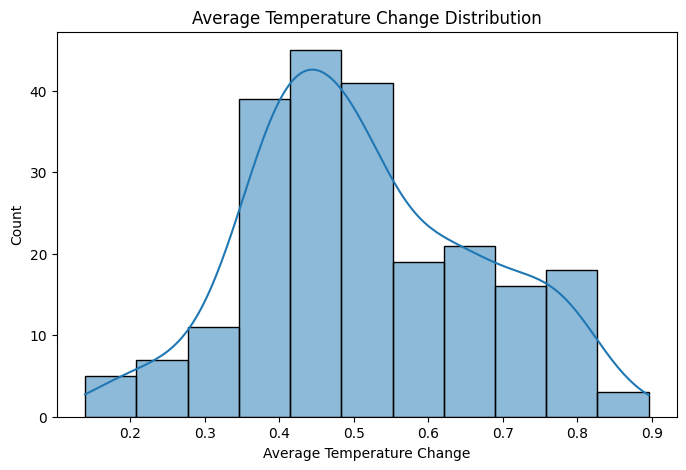

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(climate_df["Average Temperature Change"], kde=True)

plt.title("Average Temperature Change Distribution")

plt.show()

# Boxplot

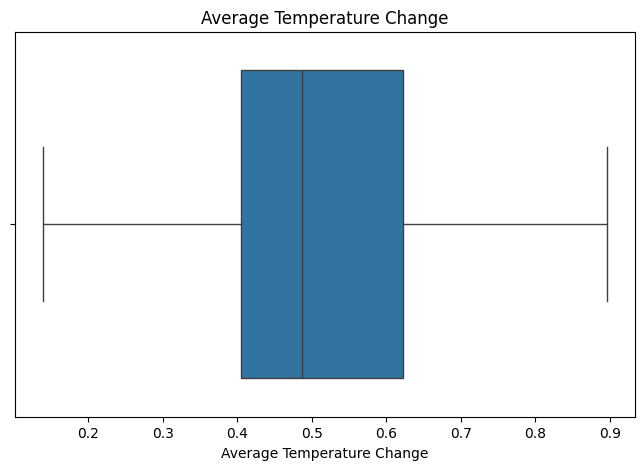

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=climate_df["Average Temperature Change"])

plt.title("Average Temperature Change")

plt.show()

# Heatmap

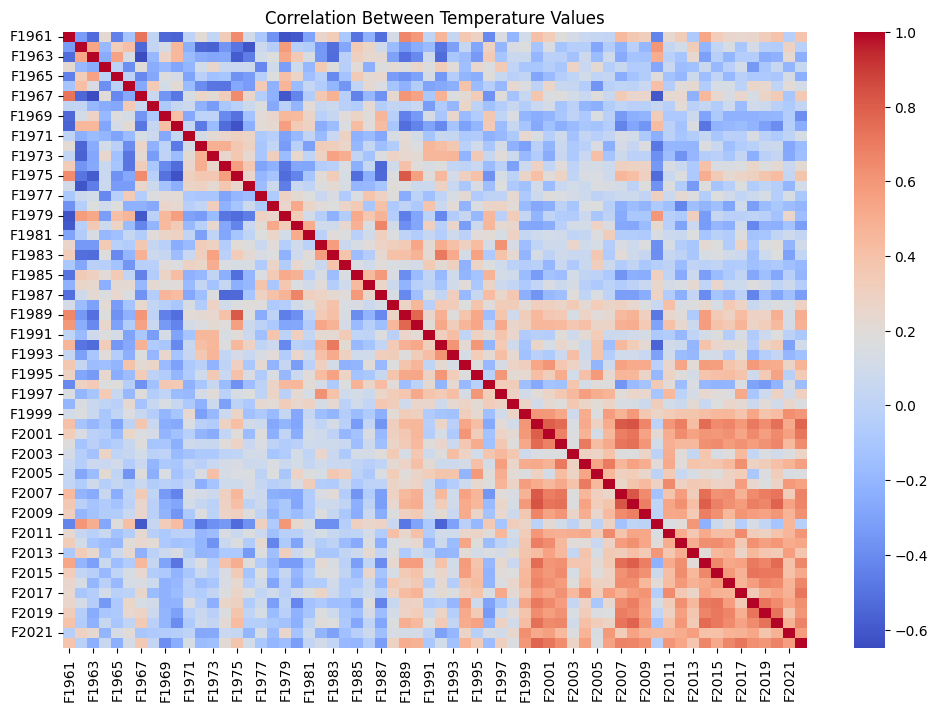

In [12]:
plt.figure(figsize=(12,8))

corr = climate_df[year_columns].corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Between Temperature Values")

plt.show()

# Scatter Plot

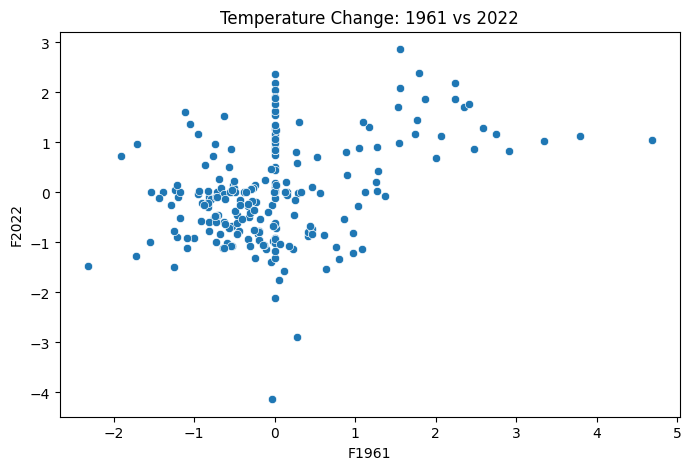

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=climate_df["F1961"],
    y=climate_df["F2022"]
)

plt.title("Temperature Change: 1961 vs 2022")

plt.show()

#  Insights

After analyzing and preprocessing the Climate Change Indicators dataset, the following insights were observed:

- Temperature change values vary significantly across different countries, indicating that climate change impacts are not uniform worldwide.
- The data from recent years generally shows higher temperature changes compared to earlier years, suggesting a long-term warming trend.
- Missing values were handled using **Mean Imputation** because the yearly temperature values are numerical, and replacing missing values with the mean helps preserve the overall distribution of the data.
- A new feature named **Average Temperature Change** was created by calculating the average of all yearly temperature values for each country. This provides a single representative value for long-term climate analysis.
- **StandardScaler** was applied to all numerical columns so that they are on the same scale. This improves the performance of machine learning algorithms and prevents features with larger values from dominating the analysis.
- **Label Encoding** was used to convert categorical columns such as **Country**, **Indicator**, and **Unit** into numerical values, making the dataset suitable for machine learning models.
- **Seaborn** visualizations helped understand the distribution of temperature changes, identify possible outliers, and explore relationships between different years through graphs and plots.
- After preprocessing, the dataset became cleaner, more consistent, and ready for further statistical analysis, visualization, and predictive modeling related to climate change and sustainability.



#  Conclusion

The dataset was successfully imported, explored, cleaned, and preprocessed. Missing values were handled appropriately, a new feature was created through feature engineering, numerical data was scaled, categorical data was encoded, and multiple visualizations were generated using Seaborn. These preprocessing steps improve the quality of the dataset and make it suitable for advanced data analysis and machine learning applications.